# Sentiment Analysis Assignment

This notebook builds a tweet sentiment classifier using two feature representations (Bag-of-Words and TF-IDF) and two non-neural statistical classifiers (Multinomial Naive Bayes and Linear SVM).

Dataset files expected in the same working directory: `train.csv` and `test.csv`.

In [75]:
import pandas as pd, re, html, unicodedata
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Load the training and test splits
train = pd.read_csv('train.csv', encoding='cp1252')
test = pd.read_csv('test.csv', encoding='cp1252')

# Keep only the raw text and sentiment label for the classification task
# Other metadata columns are excluded to keep the focus on text-based sentiment analysis
train = train[["text", "sentiment"]].copy()
test = test[["text", "sentiment"]].copy()
train = train.dropna(subset=["text", "sentiment"])
test = test.dropna(subset=["text", "sentiment"])

# Convert to string to avoid type issues during preprocessing
train["text"] = train["text"].astype(str)
test["text"] = test["text"].astype(str)
train["sentiment"] = train["sentiment"].astype(str)
test["sentiment"] = test["sentiment"].astype(str)

print(train.head())
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nClass distribution (train):")
print(train["sentiment"].value_counts())

                                                text sentiment
0                I`d have responded, if I were going   neutral
1      Sooo SAD I will miss you here in San Diego!!!  negative
2                          my boss is bullying me...  negative
3                     what interview! leave me alone  negative
4   Sons of ****, why couldn`t they put them on t...  negative
Train shape: (27480, 2)
Test shape: (3534, 2)

Class distribution (train):
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


## 1. Preprocessing for sentiment analysis

Choices used here are deliberately sentiment-aware:
- lowercasing for vocabulary reduction
- Replace URLs and user mentions with generic placeholders which reduces sparsity while preserving their discourse function
- Preserve hashtag words because hashtags often carry sentiment or topic cues
- contraction expansion, especially negation (e.g. *can't -> can not*)
- repeated character reduction for noisy tweets
- punctuation cleaning while keeping `!` and `?` as sentiment cues

Stop-word removal and stemming are intentionally avoided because they can discard useful polarity markers such as *not*, *never*, *but*, and stylistic emphasis.

In [76]:
def preprocess_text(text):
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text).lower()

    # Replace URLs and mentions with tokens
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"@\w+", " USER ", text)

    # Keep hashtag words but remove the #
    text = re.sub(r"#(\w+)", r" \1 ", text)

    # Expand useful contractions for sentiment
    text = text.replace("won't", "will not")
    text = text.replace("can't", "can not")
    text = re.sub(r"n['’]t\b", " not", text)
    text = re.sub(r"['’]re\b", " are", text)
    text = re.sub(r"['’]m\b", " am", text)
    text = re.sub(r"['’]ll\b", " will", text)
    text = re.sub(r"['’]ve\b", " have", text)
    text = re.sub(r"['’]d\b", " would", text)
    text = re.sub(r"['’]s\b", " is", text)
    
    # Reduce very long character repetitions: soooo -> soo
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Keep letters, numbers, spaces, ! and ?
    text = re.sub(r"[^a-z0-9!?_\s]", " ", text)

    # Normalize spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

X_train = train["text"].map(preprocess_text)
y_train = train["sentiment"]

X_test = test["text"].map(preprocess_text)
y_test = test["sentiment"]

print("\nExample after preprocessing:")
print(X_train.iloc[0])


Example after preprocessing:
i d have responded if i were going


## 2. Feature extraction and model training

We compare two vector spaces and two statistical classifiers:
1. Bag-of-Words + MultinomialNB
2. Bag-of-Words + LinearSVC
3. TF-IDF + MultinomialNB
4. TF-IDF + LinearSVC

Build two text representations:
- Bag-of-Words uses raw term counts
- TF-IDF down-weights very frequent words

In [77]:
# Unigrams are used in the main comparison to keep the core experiment simple and interpretable
bow = CountVectorizer(
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.95,
    max_features=5000
)

# sublinear_tf scales very frequent terms more softly, which can help TF-IDF on noisy text
tfidf = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.95,
    max_features=5000,
    sublinear_tf=True
)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [78]:
# Run all four combinations of representation and classifier
# This allows a fair comparison of both feature extraction and model choice
experiments = {
    "BoW + MultinomialNB": (X_train_bow, X_test_bow, MultinomialNB()),
    "BoW + LinearSVC": (X_train_bow, X_test_bow, LinearSVC()),
    "TF-IDF + MultinomialNB": (X_train_tfidf, X_test_tfidf, MultinomialNB()),
    "TF-IDF + LinearSVC": (X_train_tfidf, X_test_tfidf, LinearSVC()),
}

results = []
predictions = {}

for name, (Xtr, Xte, clf) in experiments.items():
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    predictions[name] = pred

    # Macro F1 is included because it gives equal weight to each sentiment class
    results.append({
        "Experiment": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Macro F1": f1_score(y_test, pred, average="macro")
    })

results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False)
print(results_df)

best_model_name = results_df.iloc[0]["Experiment"]
best_pred = predictions[best_model_name]

print("\nBest model:", best_model_name)
print("\nClassification report:")
print(classification_report(y_test, best_pred))

               Experiment  Accuracy  Macro F1
3      TF-IDF + LinearSVC  0.700623  0.703172
1         BoW + LinearSVC  0.681947  0.684471
0     BoW + MultinomialNB  0.669213  0.672463
2  TF-IDF + MultinomialNB  0.655914  0.650984

Best model: TF-IDF + LinearSVC

Classification report:
              precision    recall  f1-score   support

    negative       0.69      0.67      0.68      1001
     neutral       0.66      0.69      0.67      1430
    positive       0.77      0.74      0.76      1103

    accuracy                           0.70      3534
   macro avg       0.71      0.70      0.70      3534
weighted avg       0.70      0.70      0.70      3534


## 3. Results from the run used in the report

This section presents the quantitative results used in the report.

- A bar chart compares all feature extractor and classifier combinations using Accuracy and Macro F1.
- The class distribution is visualised because imbalance can influence aggregate metrics.
- A confusion matrix is shown for the best-performing model to identify which sentiment classes are most often confused.

In [84]:
results = []
predictions = {}

for name, (Xtr, Xte, clf) in experiments.items():
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    predictions[name] = pred

    results.append({
        "Experiment": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Macro F1": f1_score(y_test, pred, average="macro")
    })

results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False)
print(results_df)
print("\nInterpretation:")
print("TF-IDF + LinearSVC achieved the best overall performance, suggesting that weighting terms by informativeness helps sentiment classification more than raw counts alone.")

best_model_name = results_df.iloc[0]["Experiment"]
best_pred = predictions[best_model_name]

print("\nBest model:", best_model_name)
print("\nClassification report:")
print(classification_report(y_test, best_pred))

               Experiment  Accuracy  Macro F1
3      TF-IDF + LinearSVC  0.700623  0.703172
1         BoW + LinearSVC  0.681947  0.684471
0     BoW + MultinomialNB  0.669213  0.672463
2  TF-IDF + MultinomialNB  0.655914  0.650984

Interpretation:
TF-IDF + LinearSVC achieved the best overall performance, suggesting that weighting terms by informativeness helps sentiment classification more than raw counts alone.

Best model: TF-IDF + LinearSVC

Classification report:
              precision    recall  f1-score   support

    negative       0.69      0.67      0.68      1001
     neutral       0.66      0.69      0.67      1430
    positive       0.77      0.74      0.76      1103

    accuracy                           0.70      3534
   macro avg       0.71      0.70      0.70      3534
weighted avg       0.70      0.70      0.70      3534


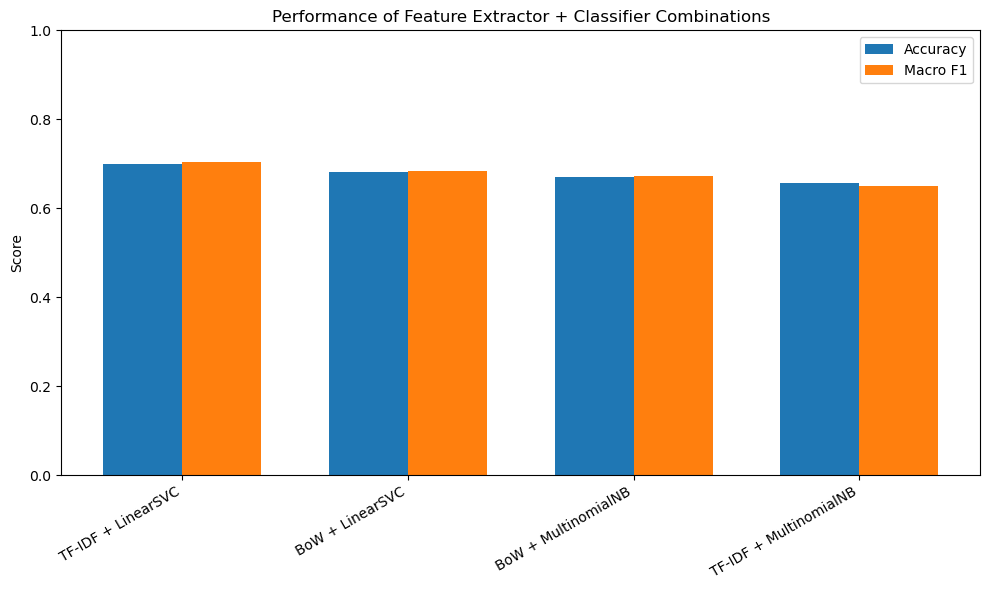

In [80]:
plot_df = results_df.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, plot_df["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, plot_df["Macro F1"], width, label="Macro F1")

plt.xticks(x, plot_df["Experiment"], rotation=30, ha="right")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Performance of Feature Extractor + Classifier Combinations")
plt.legend()
plt.tight_layout()
plt.show()

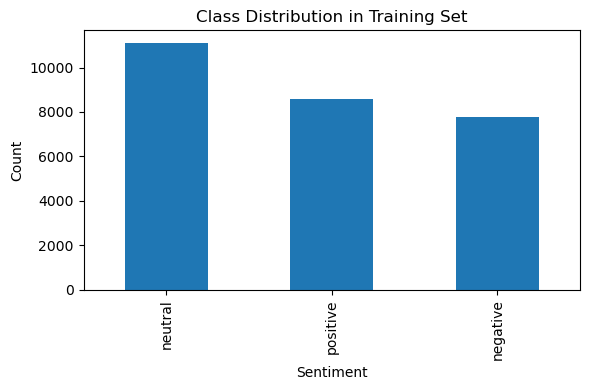

In [81]:
train["sentiment"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Class Distribution in Training Set")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

<Figure size 600x600 with 0 Axes>

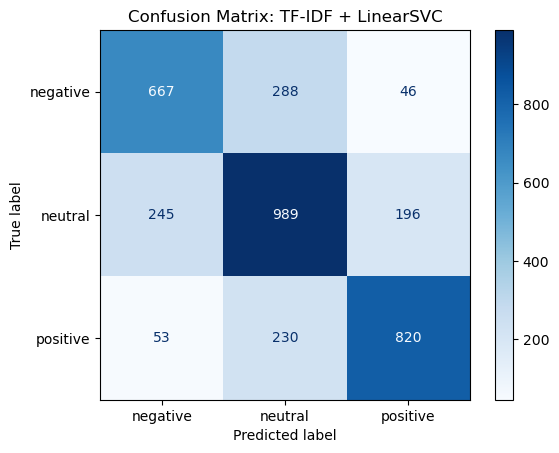

In [82]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, best_pred, labels=labels)

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

## 4. Error analysis

This section analyses misclassified examples produced by the best-performing model.

- A table of misclassified examples is created for qualitative analysis.
- Broad heuristic error categories are assigned to identify common failure patterns.
- These categories are approximate and are used to support discussion in the report rather than as a formal annotation scheme.

error_type
context/ambiguity    770
negation             186
mixed sentiment      102
Name: count, dtype: int64

--- CONTEXT/AMBIGUITY ---
TEXT: hey peoples, dont you just hate being grounded haha, im just sat eating an apple and watching death note (some anime)
TRUE LABEL: neutral | PRED: negative

TEXT:  look who I found just for you  --->  http://twitter.com/DJT2009
TRUE LABEL: positive | PRED: neutral

TEXT: So I really need to put the laptop down & start getting ready for  shindig...But I`ve missed my TwitterLoves all day
TRUE LABEL: neutral | PRED: negative


--- NEGATION ---
TEXT: There is a faux gothy chick looking at me, sorry I am not going to camden and I like pop-punk and jimmy eat world
TRUE LABEL: neutral | PRED: negative

TEXT:  4n? ma rog  never heard of it  esti beat acum? u tweet too much
TRUE LABEL: negative | PRED: neutral

TEXT: Not happy
TRUE LABEL: negative | PRED: positive


--- MIXED SENTIMENT ---
TEXT: man im so sad school is ending  but then again high school

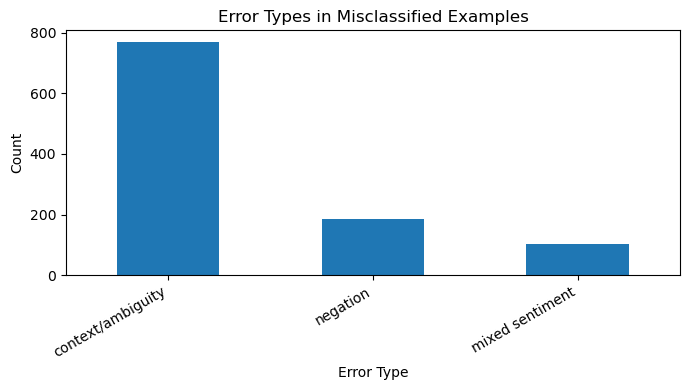

In [83]:
error_df = pd.DataFrame({
    "text": test["text"].values,
    "true_label": y_test.values,
    "pred": best_pred
})

error_df = error_df[error_df["true_label"] != error_df["pred"]].copy()

def assign_error_type(text):
    t = str(text).lower()

    if re.search(r"\b(no|not|never|nothing|without|cannot|can't|won't|don't|didn't|isn't|wasn't|shouldn't|couldn't)\b", t):
        return "negation"
    elif any(x in t for x in [" but ", " although ", " though ", " however ", " yet ", " while "]):
        return "mixed sentiment"
    elif any(x in t for x in ["yeah right", "as if", "thanks a lot", "great...", "lovely...", "nice..."]):
        return "sarcasm/irony"
    else:
        return "context/ambiguity"

error_df["error_type"] = error_df["text"].map(assign_error_type)

print(error_df["error_type"].value_counts())

for error_type in error_df["error_type"].unique():
    print(f"\n--- {error_type.upper()} ---")
    sample = error_df[error_df["error_type"] == error_type].head(3)
    for _, row in sample.iterrows():
        print("TEXT:", row["text"])
        print("TRUE LABEL:", row["true_label"], "| PRED:", row["pred"])
        print()

error_df["error_type"].value_counts().plot(kind="bar", figsize=(7,4))
plt.title("Error Types in Misclassified Examples")
plt.xlabel("Error Type")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()